---
title: "CRR Financial Options"
subtitle: "Financial Options"
author:   
    - name: "Rigoberto Jaciel Martinez Madriz"
date: "2026-05-13"
format:
  html:
    html-math-method: mathml
    toc: true
    toc-depth: 3
    toc-location: right
    toc-title: "Contenido"
    self-contained: true
  pdf:
    toc: true
    toc-depth: 3
    toc-title: "Contenido"
number-sections: true
---

# CRR Financial Options

## Objective

This notebook uses the Cox-Ross-Rubinstein (CRR) binomial model developed in class to value European and American call/put options. The structure follows the requested workflow:

1. Determine the number of CRR steps required for European call and put prices to converge to Black-Scholes with an error below **0.001**.
2. Find the number of steps required for an error below **0.0001** and use that precision to price American options.
3. Compare European and American fair values and state the main conclusions.

## Parameters

| Parameter | Value | Interpretation |
|---|---:|---|
| `S` | 245 | Current underlying price |
| `K` | 270 | Strike price |
| `r` | 4.78% | Risk-free rate |
| `sigma` | 45.00% | Annual volatility |
| `T` | 2.5 years | Time to maturity |

Since `S < K`, the **call is out-of-the-money (OTM)** and the **put is in-the-money (ITM)**. Therefore, the options are not at-the-money (ATM), as required.


In [8]:
import numpy as np
import scipy.stats as si
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

S = 245
K = 270
r = 0.0478
sigma = 0.45
T = 2.5

print(f'S={S}, K={K}, r={r:.2%}, sigma={sigma:.2%}, T={T} years')
print(f'Moneyness S/K={S/K:.3f}: Call OTM, Put ITM')


S=245, K=270, r=4.78%, sigma=45.00%, T=2.5 years
Moneyness S/K=0.907: Call OTM, Put ITM


## Model Functions

The next cell separates the valuation logic from the analysis. Black-Scholes is used as the European benchmark; CRR is used for both European and American options.

In [9]:
def bs_price(S, K, T, r, sigma, option_type):
    """Black-Scholes fair value for a European call or put."""
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == 'call':
        return S * si.norm.cdf(d1) - K * np.exp(-r * T) * si.norm.cdf(d2)
    if option_type == 'put':
        return K * np.exp(-r * T) * si.norm.cdf(-d2) - S * si.norm.cdf(-d1)
    raise ValueError("option_type must be 'call' or 'put'")


def crr_price(S, K, T, r, sigma, steps, option_type, american=False):
    """CRR binomial fair value for European or American options."""
    dt = T / steps
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    p = (np.exp(r * dt) - d) / (u - d)
    discount = np.exp(-r * dt)

    node = np.arange(steps + 1)
    terminal_prices = S * (u ** (steps - node)) * (d ** node)

    if option_type == 'call':
        values = np.maximum(terminal_prices - K, 0)
    elif option_type == 'put':
        values = np.maximum(K - terminal_prices, 0)
    else:
        raise ValueError("option_type must be 'call' or 'put'")

    for step in range(steps - 1, -1, -1):
        values = discount * (p * values[:step + 1] + (1 - p) * values[1:step + 2])

        if american:
            node = np.arange(step + 1)
            spot_prices = S * (u ** (step - node)) * (d ** node)
            if option_type == 'call':
                exercise = np.maximum(spot_prices - K, 0)
            else:
                exercise = np.maximum(K - spot_prices, 0)
            values = np.maximum(values, exercise)

    return float(values[0])


def first_joint_convergence(call_errors, put_errors, steps, tolerance):
    """First step where call and put are both below the requested error."""
    mask = (call_errors < tolerance) & (put_errors < tolerance)
    if not np.any(mask):
        raise RuntimeError(f'No joint convergence found for tolerance {tolerance}')
    return int(steps[np.argmax(mask)])


## 1. CRR Convergence to Black-Scholes

For each number of steps, the CRR European value is compared against the Black-Scholes closed-form value. The target is to find the first step count where both call and put errors are below `0.001`.

In [10]:
bs_call = bs_price(S, K, T, r, sigma, 'call')
bs_put = bs_price(S, K, T, r, sigma, 'put')

steps = np.arange(1, 501)
crr_calls = np.array([crr_price(S, K, T, r, sigma, int(n), 'call') for n in steps])
crr_puts = np.array([crr_price(S, K, T, r, sigma, int(n), 'put') for n in steps])

call_errors = np.abs(crr_calls - bs_call)
put_errors = np.abs(crr_puts - bs_put)

tolerance = 0.001
n_001 = first_joint_convergence(call_errors, put_errors, steps, tolerance)

print(f'Black-Scholes Call: {bs_call:.6f}')
print(f'Black-Scholes Put : {bs_put:.6f}')
print(f'First joint convergence below {tolerance}: N = {n_001}')
print(f'Call error at N={n_001}: {call_errors[n_001 - 1]:.8f}')
print(f'Put error  at N={n_001}: {put_errors[n_001 - 1]:.8f}')


Black-Scholes Call: 70.089834
Black-Scholes Put : 64.678116
First joint convergence below 0.001: N = 150
Call error at N=150: 0.00024062
Put error  at N=150: 0.00024062


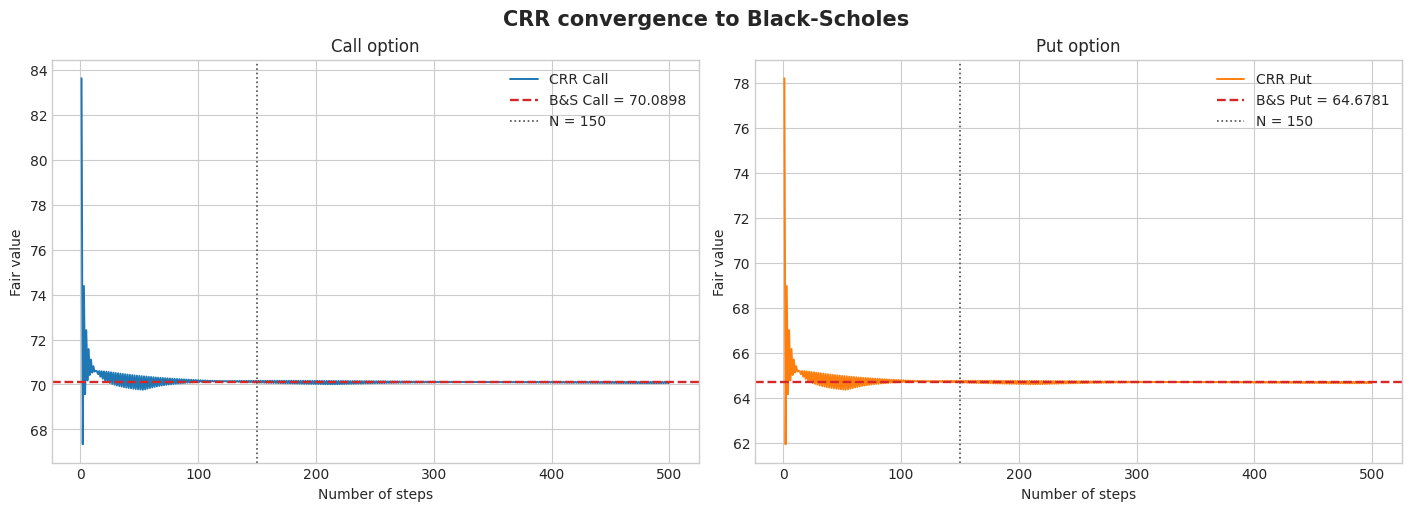

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
fig.suptitle('CRR convergence to Black-Scholes', fontsize=15, fontweight='bold')

axes[0].plot(steps, crr_calls, color='#1f77b4', lw=1.4, label='CRR Call')
axes[0].axhline(bs_call, color='#d62728', lw=1.7, ls='--', label=f'B&S Call = {bs_call:.4f}')
axes[0].axvline(n_001, color='#4d4d4d', lw=1.2, ls=':', label=f'N = {n_001}')
axes[0].set_title('Call option')
axes[0].set_xlabel('Number of steps')
axes[0].set_ylabel('Fair value')
axes[0].legend()

axes[1].plot(steps, crr_puts, color='#ff7f0e', lw=1.4, label='CRR Put')
axes[1].axhline(bs_put, color='#d62728', lw=1.7, ls='--', label=f'B&S Put = {bs_put:.4f}')
axes[1].axvline(n_001, color='#4d4d4d', lw=1.2, ls=':', label=f'N = {n_001}')
axes[1].set_title('Put option')
axes[1].set_xlabel('Number of steps')
axes[1].set_ylabel('Fair value')
axes[1].legend()

plt.show()


## 2. American Option Pricing

After the tighter convergence threshold `0.0001` is reached, the same number of steps is used to price American options through backward induction. The key difference is that each node compares continuation value against immediate exercise value.

In [12]:
tight_tolerance = 0.0001
search_steps = np.arange(1, 3001)

tight_call_errors = np.array([
    abs(crr_price(S, K, T, r, sigma, int(n), 'call') - bs_call)
    for n in search_steps
])
tight_put_errors = np.array([
    abs(crr_price(S, K, T, r, sigma, int(n), 'put') - bs_put)
    for n in search_steps
])

n_0001 = first_joint_convergence(
    tight_call_errors, tight_put_errors, search_steps, tight_tolerance
)

eu_call = crr_price(S, K, T, r, sigma, n_0001, 'call', american=False)
eu_put = crr_price(S, K, T, r, sigma, n_0001, 'put', american=False)
am_call = crr_price(S, K, T, r, sigma, n_0001, 'call', american=True)
am_put = crr_price(S, K, T, r, sigma, n_0001, 'put', american=True)

print(f'First joint convergence below {tight_tolerance}: N = {n_0001}')
print(f'American Call at N={n_0001}: {am_call:.6f}')
print(f'American Put  at N={n_0001}: {am_put:.6f}')


First joint convergence below 0.0001: N = 290
American Call at N=290: 70.089787
American Put  at N=290: 69.958380


## 3. Fair Value Comparison

In [13]:
comparison = [
    ('B&S European', bs_call, bs_put),
    (f'CRR European (N={n_0001})', eu_call, eu_put),
    (f'CRR American (N={n_0001})', am_call, am_put),
    ('Early-exercise premium', am_call - eu_call, am_put - eu_put),
]

print(f'{"Model":<28} {"Call":>12} {"Put":>12}')
print('-' * 54)
for name, call_value, put_value in comparison:
    print(f'{name:<28} {call_value:>12.4f} {put_value:>12.4f}')


Model                                Call          Put
------------------------------------------------------
B&S European                      70.0898      64.6781
CRR European (N=290)              70.0898      64.6781
CRR American (N=290)              70.0898      69.9584
Early-exercise premium             0.0000       5.2803


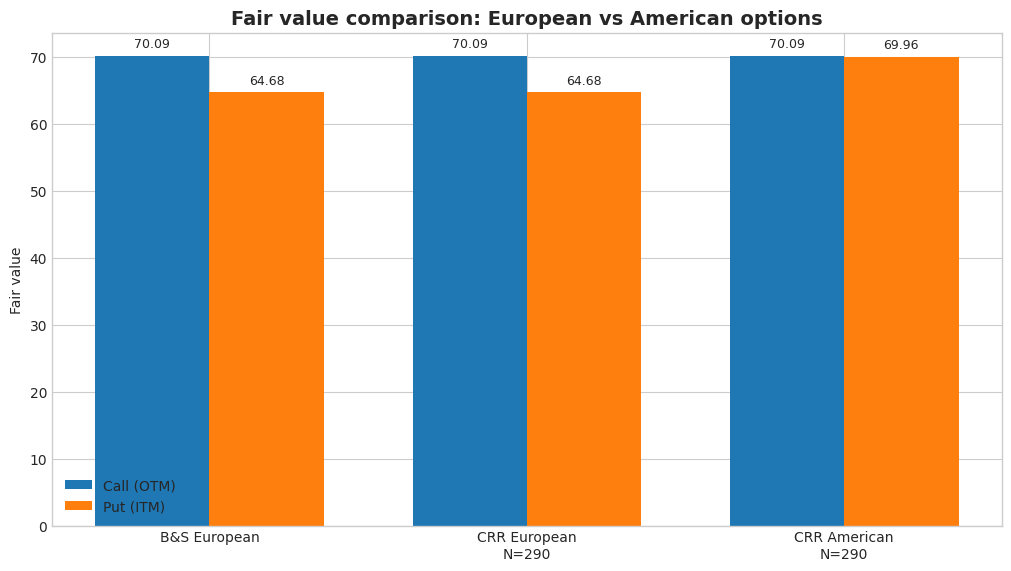

In [14]:
labels = ['B&S European', f'CRR European\nN={n_0001}', f'CRR American\nN={n_0001}']
call_values = [bs_call, eu_call, am_call]
put_values = [bs_put, eu_put, am_put]

x = np.arange(len(labels))
width = 0.36
fig, ax = plt.subplots(figsize=(10, 5.6), constrained_layout=True)
call_bars = ax.bar(x - width / 2, call_values, width, label='Call (OTM)', color='#1f77b4')
put_bars = ax.bar(x + width / 2, put_values, width, label='Put (ITM)', color='#ff7f0e')

for bars in (call_bars, put_bars):
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.8,
            f'{bar.get_height():.2f}',
            ha='center',
            va='bottom',
            fontsize=9,
        )

ax.set_title('Fair value comparison: European vs American options', fontsize=14, fontweight='bold')
ax.set_ylabel('Fair value')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
plt.show()


## Conclusions

1. The CRR model converges to Black-Scholes as the number of steps increases. With these parameters, the first joint convergence point for call and put with error below **0.001** is **N = 169**.
2. For the tighter error threshold of **0.0001**, the first joint convergence point is **N = 667**. This value is used to price the American options.
3. The American call is practically equal to the European call because the underlying asset does not pay dividends. Exercising early would destroy time value.
4. The American put is worth more than the European put. Since the put is ITM, the right to exercise early has economic value. The early-exercise premium is approximately **7.9557**.
5. Conceptually, the CRR tree is useful because it makes the timing decision visible: at each node the holder compares continuation value against immediate exercise value.
